# Hybrid Retrieval + Generation Ablation — Người 3 (Kiệt) — v3

| # | Config | Dense | BM25 | Mục tiêu |
|---|--------|-------|------|----------|
| 1 | `Dense-ChunkMeta` | ✅ | ❌ | Dense baseline (chunk+metadata) |
| 2 | `BM25-Only` | ❌ | ✅ | BM25 sparse baseline |
| 3 | `Retrieval-Hybrid-SparseDense` | ✅ | ✅ | Hybrid score merge |

**Retrieval metrics**: Recall@k, MRR@k, nDCG@k, Hit@k, Precision@k  
**Generation metrics**: Exact Match, Token F1, ROUGE-L, Citation count  
**Generator**: gpt-4o-mini via OpenAI-compatible API

---

## 1. Install & Imports

In [1]:
!pip install -q rank_bm25 sentence-transformers faiss-cpu underthesea openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.3 MB/s eta 0:00:00


In [2]:
import json, os, sys, time, math, pickle, re, unicodedata, gc, hashlib
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Sequence
from collections import defaultdict, Counter
from datetime import datetime, timezone
import numpy as np
print('Setup complete.')

Setup complete.


## 2. Configuration

In [3]:
IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    FAISS_DIR = Path('/kaggle/input/datasets/kittrntunk/faiss-chunk-meta')
    BM25_BASE_DIR = Path('/kaggle/input/datasets/nguyenlethienlyy/bm25-tokenized/bm25')
    QA_DIR = Path('/kaggle/input/datasets/phuongthao205/qa-legalrag/Benchmark')
    OUTPUT_BASE = Path('/kaggle/working/evaluation_runs/ablation')
else:
    PROJECT_ROOT = Path('.').resolve()
    if not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    FAISS_DIR = PROJECT_ROOT / 'data' / 'faiss_index'
    BM25_BASE_DIR = PROJECT_ROOT / 'data' / 'sparse_index'
    QA_DIR = PROJECT_ROOT / 'data' / 'benchmark'
    OUTPUT_BASE = PROJECT_ROOT / 'evaluation_runs' / 'ablation'

# === RETRIEVAL ===
EMBEDDING_MODEL = 'intfloat/multilingual-e5-large'
TOP_K = 30
TOP_N = 10
SCORE_THRESHOLD = 0.30
TOP_K_EVAL = [1, 3, 5, 10]
ABLATION_LIMIT = None  # Set 5 để smoke test

# === GENERATOR ===
LLM_BASE_URL = 'https://api.shopaikey.com/v1'
LLM_API_KEY = 'sk-5EAiA6CNDAmXwyewsIMXf4rsZWSkdAGijaEqBFKlWOCC954Z'
LLM_MODEL = 'gpt-4o-mini'
GEN_TEMPERATURE = 0.0
GEN_MAX_TOKENS = 1024
GEN_TIMEOUT = 60

os.environ['CUDA_VISIBLE_DEVICES'] = ''  # Force CPU

print('Environment:', 'Kaggle' if IS_KAGGLE else 'Local')
print(f'Generator: {LLM_MODEL} @ {LLM_BASE_URL}')

Environment: Kaggle
Generator: gpt-4o-mini @ https://api.shopaikey.com/v1


## 3. Verify Paths

In [4]:
def verify_path(path, desc):
    ok = path.exists()
    print(f'  {"✅" if ok else "❌"} {desc}: {path}')
    return ok

print('=== Kiểm tra paths ===')
ok1 = verify_path(FAISS_DIR, 'FAISS')
ok2 = verify_path(BM25_BASE_DIR, 'BM25')
ok3 = verify_path(QA_DIR, 'QA')

BENCHMARK_PATH = None
if ok3:
    for p in ['qa_final.jsonl', '*.jsonl']:
        found = list(QA_DIR.glob(p))
        if found:
            BENCHMARK_PATH = found[0]
            break
    print(f'  📝 Benchmark: {BENCHMARK_PATH}')

if ok2:
    shards = sorted([d for d in BM25_BASE_DIR.iterdir() if d.is_dir() and d.name.startswith('shard_')])
    print(f'  📦 BM25 shards: {len(shards)}')

if not all([ok1, ok2, ok3, BENCHMARK_PATH]):
    print('\n⚠️ PATHS KHÔNG ĐÚNG! Chạy: !find /kaggle/input -maxdepth 4 -type d')
else:
    print('\n✅ OK!')

=== Kiểm tra paths ===
  ✅ FAISS: /kaggle/input/datasets/kittrntunk/faiss-chunk-meta
  ✅ BM25: /kaggle/input/datasets/nguyenlethienlyy/bm25-tokenized/bm25
  ✅ QA: /kaggle/input/datasets/phuongthao205/qa-legalrag/Benchmark
  📝 Benchmark: /kaggle/input/datasets/phuongthao205/qa-legalrag/Benchmark/qa_final.jsonl
  📦 BM25 shards: 10

✅ OK!


## 4. Schema, Metrics, Generator Utils

In [5]:
# === SCHEMA ===
@dataclass(frozen=True)
class SearchHit:
    point_id: str
    score: float
    payload: dict[str, Any]

@dataclass(frozen=True)
class LatencyBreakdown:
    dense_latency_s: float = 0.0
    sparse_latency_s: float = 0.0
    fusion_latency_s: float = 0.0
    generation_latency_s: float = 0.0
    total_latency_s: float = 0.0
    def to_dict(self):
        return {k: round(v, 4) for k, v in {
            'dense_latency_s': self.dense_latency_s,
            'sparse_latency_s': self.sparse_latency_s,
            'fusion_latency_s': self.fusion_latency_s,
            'generation_latency_s': self.generation_latency_s,
            'total_latency_s': self.total_latency_s,
        }.items()}

print('Schema defined.')

Schema defined.


In [6]:
# === RETRIEVAL METRICS ===
def recall_at_k(ret, rel, k):
    return len(set(ret[:k]) & rel) / len(rel) if rel else 0.0
def hit_at_k(ret, rel, k):
    return 1.0 if rel and set(ret[:k]) & rel else 0.0
def mrr_at_k(ret, rel, k):
    if not rel: return 0.0
    for i, c in enumerate(ret[:k], 1):
        if c in rel: return 1.0/i
    return 0.0
def ndcg_at_k(ret, rel, k):
    if not rel: return 0.0
    dcg = sum(1.0/math.log2(i+1) for i, c in enumerate(ret[:k], 1) if c in rel)
    ideal = sum(1.0/math.log2(i+1) for i in range(1, min(len(rel), k)+1))
    return dcg/ideal if ideal else 0.0
def precision_at_k(ret, rel, k):
    return len(set(ret[:k]) & rel) / k if k else 0.0

# === GENERATION METRICS ===
_PUNCT_RE = re.compile(r'[^\w\s]', flags=re.UNICODE)
_SPACE_RE = re.compile(r'\s+')

def normalize_text(text):
    text = '' if text is None else str(text)
    text = unicodedata.normalize('NFC', text).lower()
    text = _PUNCT_RE.sub(' ', text)
    return _SPACE_RE.sub(' ', text).strip()

def tokenize_text(text):
    n = normalize_text(text)
    return n.split() if n else []

def exact_match(pred, ref):
    return 1.0 if normalize_text(pred) == normalize_text(ref) else 0.0

def token_f1(pred, ref):
    pt, rt = tokenize_text(pred), tokenize_text(ref)
    if not pt and not rt: return 1.0
    if not pt or not rt: return 0.0
    common = sum((Counter(pt) & Counter(rt)).values())
    if common == 0: return 0.0
    p, r = common/len(pt), common/len(rt)
    return 2*p*r/(p+r)

def _lcs_len(a, b):
    prev = [0]*(len(b)+1)
    for ta in a:
        curr = [0]
        for j, tb in enumerate(b, 1):
            curr.append(prev[j-1]+1 if ta == tb else max(prev[j], curr[-1]))
        prev = curr
    return prev[-1]

def rouge_l(pred, ref):
    pt, rt = tokenize_text(pred), tokenize_text(ref)
    if not pt and not rt: return 1.0
    if not pt or not rt: return 0.0
    lcs = _lcs_len(pt, rt)
    p, r = lcs/len(pt), lcs/len(rt)
    return 2*p*r/(p+r) if (p+r) else 0.0

def is_unanswerable_text(text):
    n = normalize_text(text)
    markers = ['không có đủ thông tin', 'không đủ thông tin', 'không đủ căn cứ',
               'không tìm thấy', 'không có thông tin']
    return any(m in n for m in markers)

# === AGGREGATION ===
def aggregate_metrics(rows, keys):
    out = {'count': len(rows)}
    for k in keys:
        vals = [float(r[k]) for r in rows if r.get(k) is not None]
        out[k] = sum(vals)/len(vals) if vals else None
    return out

def aggregate_by(rows, field, keys):
    groups = defaultdict(list)
    for r in rows: groups[str(r.get(field) or 'unknown')].append(r)
    return {n: aggregate_metrics(g, keys) for n, g in sorted(groups.items())}

RET_METRIC_KEYS = [f'{n}@{k}' for k in TOP_K_EVAL for n in ['recall','hit','mrr','ndcg','precision']]
GEN_METRIC_KEYS = ['exact_match', 'token_f1', 'rouge_l', 'unanswerable_accuracy']
ALL_METRIC_KEYS = RET_METRIC_KEYS + GEN_METRIC_KEYS

print('Metrics defined.')

Metrics defined.


In [7]:
# === GENERATOR — Prompt & Parser ===

INSUFFICIENT_CONTEXT = 'Không có đủ thông tin trong ngữ cảnh được cung cấp.'

PROMPT_TEMPLATE = """You are a Vietnamese legal retrieval-augmented answering system.
Use only the supplied CONTEXT. Do not invent facts outside it.
If the context is insufficient, answer exactly:
"{insufficient}"

Answer the question directly from the context.

Output contract:
- Return only the final answer; never reveal hidden reasoning or chain-of-thought.
- For answer_type "boolean", the first line must be exactly "Có" or "Không";
  any explanation follows a line beginning "Giải thích:".
- For answer_type "unanswerable", return only the insufficient-context statement.
- Otherwise answer concisely in Vietnamese.
- Cite supporting context with [1], [2], etc. immediately after the claim.
- Do not add a bibliography. Cite only a source that supports the claim.

QUESTION:
{question}

ANSWER_TYPE:
{answer_type}

CONTEXT:
{context}

FINAL ANSWER:"""

_THINK_RE = re.compile(r'<think>.*?</think>', re.DOTALL | re.IGNORECASE)
_CITE_RE = re.compile(r'\[\s*(\d+)\s*\]')

def format_chunks_as_context(hits):
    """Format SearchHit list as numbered sources for prompt."""
    blocks = []
    for i, hit in enumerate(hits, 1):
        p = hit.payload
        lines = [f'[SOURCE {i}]']
        for label, key in [('Title', 'title'), ('Article', 'article_number'),
                           ('Section', 'citation_anchor'), ('Chunk ID', 'chunk_id')]:
            v = p.get(key)
            if v: lines.append(f'{label}: {v}')
        text = str(p.get('chunk_text') or p.get('text') or '')
        lines.extend(['Content:', text[:4000]])
        blocks.append('\n'.join(lines))
    return '\n\n'.join(blocks)

def build_prompt(question, answer_type, hits):
    ctx = format_chunks_as_context(hits)
    return PROMPT_TEMPLATE.format(
        insufficient=INSUFFICIENT_CONTEXT,
        question=question.strip(),
        answer_type=(answer_type or '').strip(),
        context=ctx,
    )

def parse_answer(raw_text):
    """Strip <think> blocks, return clean answer."""
    text = _THINK_RE.sub('', raw_text or '').strip()
    return text

def count_citations(text):
    """Count unique citation markers [N] in answer."""
    return len(set(_CITE_RE.findall(text or '')))

print('Generator utils defined.')

Generator utils defined.


In [8]:
# === GENERATOR CLIENT ===
from openai import OpenAI

gen_client = OpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY)

def call_llm(prompt, *, temperature=GEN_TEMPERATURE, max_tokens=GEN_MAX_TOKENS):
    """Call LLM, return raw text. Raises on error."""
    resp = gen_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[{'role': 'user', 'content': prompt}],
        temperature=temperature,
        max_tokens=max_tokens,
        timeout=GEN_TIMEOUT,
    )
    return (resp.choices[0].message.content or '').strip()

# Smoke test
print('Testing LLM...')
test_resp = call_llm('Trả lời bằng tiếng Việt: 1+1 bằng mấy?')
print(f'  Response: {test_resp[:200]}')
print('✅ Generator ready.')

Testing LLM...
  Response: 1 + 1 bằng 2.
✅ Generator ready.


## 5. Load QA Benchmark

In [9]:
print(f'Loading benchmark from {BENCHMARK_PATH} ...')
qa_data = []
with open(BENCHMARK_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line: qa_data.append(json.loads(line))
print(f'Loaded {len(qa_data):,} QA items')

# Build eval set — include all with ground_truth chunk_ids
eval_qa = []
skip_no_gt = 0
for qa in qa_data:
    gt = qa.get('ground_truth') or {}
    gt_chunks = {str(c) for c in gt.get('chunk_ids') or [] if c}
    at = str(qa.get('answer_type') or '').lower()
    cat = str(qa.get('category') or '').lower()
    is_unanswerable = (at == 'unanswerable' or cat == 'unanswerable')
    if not gt_chunks and not is_unanswerable:
        skip_no_gt += 1
        continue
    eval_qa.append((qa, gt_chunks, is_unanswerable))

if ABLATION_LIMIT:
    eval_qa = eval_qa[:ABLATION_LIMIT]

n_unans = sum(1 for _,_,u in eval_qa if u)
n_ans = len(eval_qa) - n_unans
print(f'Eval: {len(eval_qa)} total ({n_ans} answerable + {n_unans} unanswerable) | Skipped: {skip_no_gt}')

Loading benchmark from /kaggle/input/datasets/phuongthao205/qa-legalrag/Benchmark/qa_final.jsonl ...
Loaded 500 QA items
Eval: 500 total (400 answerable + 100 unanswerable) | Skipped: 0


## 6. Load Dense Retriever (FAISS chunk+metadata)

In [10]:
import faiss
from sentence_transformers import SentenceTransformer

print('Loading FAISS index...')
t0 = time.perf_counter()
faiss_index = faiss.read_index(str(FAISS_DIR / 'index.faiss'))
print(f'  {faiss_index.ntotal:,} vectors, dim={faiss_index.d} ({time.perf_counter()-t0:.1f}s)')

print('Loading payloads...')
t0 = time.perf_counter()
dense_payloads = {}
with open(FAISS_DIR / 'payloads.jsonl', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        line = line.strip()
        if line: dense_payloads[i] = json.loads(line)
print(f'  {len(dense_payloads):,} payloads ({time.perf_counter()-t0:.1f}s)')

id_map_path = FAISS_DIR / 'id_map.json'
if id_map_path.exists():
    with open(id_map_path, 'r', encoding='utf-8') as f:
        raw = json.load(f)
    dense_id_map = {int(v): str(k) for k, v in raw.items()}
else:
    dense_id_map = {i: str(dense_payloads.get(i, {}).get('chunk_id', i)) for i in dense_payloads}
print(f'  ID map: {len(dense_id_map):,}')

print(f'Loading {EMBEDDING_MODEL} ...')
t0 = time.perf_counter()
embedder = SentenceTransformer(EMBEDDING_MODEL, device='cpu')
print(f'  Loaded in {time.perf_counter()-t0:.1f}s')
print('✅ Dense retriever ready.')

Loading FAISS index...
  1,513,376 vectors, dim=1024 (82.0s)
Loading payloads...
  1,513,376 payloads (153.7s)


  ID map: 1,513,376
Loading intfloat/multilingual-e5-large ...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

  Loaded in 19.5s
✅ Dense retriever ready.


In [11]:
def dense_search(query, *, top_k=30, score_threshold=0.0):
    vec = embedder.encode(['query: ' + query], normalize_embeddings=True)
    qv = np.array(vec, dtype=np.float32)
    limit = min(top_k * 3, faiss_index.ntotal)
    scores, indices = faiss_index.search(qv, limit)
    hits = []
    for sc, idx in zip(scores[0], indices[0]):
        if idx < 0 or float(sc) < score_threshold: continue
        hits.append(SearchHit(point_id=dense_id_map.get(int(idx), str(idx)),
                              score=float(sc), payload=dense_payloads.get(int(idx), {})))
        if len(hits) >= top_k: break
    return hits

def dense_search_timed(query, **kw):
    t0 = time.perf_counter()
    hits = dense_search(query, **kw)
    return hits, time.perf_counter() - t0

# Smoke test
test_q = 'Điều kiện để người lao động đơn phương chấm dứt hợp đồng lao động'
test_hits, test_lat = dense_search_timed(test_q, top_k=5, score_threshold=SCORE_THRESHOLD)
print(f'Dense smoke: {len(test_hits)} hits in {test_lat:.3f}s')

Dense smoke: 5 hits in 1.037s


## 7. BM25 Sharded Search

In [12]:
def simple_tokenize(text):
    text = unicodedata.normalize('NFC', text).lower()
    text = re.sub(r'[^\w\s]', ' ', text, flags=re.UNICODE)
    return [t for t in text.split() if len(t) > 1]

try:
    from underthesea import word_tokenize as _ws
    def bm25_tokenize(text):
        return simple_tokenize(_ws(text, format='text'))
    print('✅ underthesea tokenizer')
except ImportError:
    bm25_tokenize = simple_tokenize
    print('⚠️ simple tokenizer')

✅ underthesea tokenizer


In [13]:
# Pre-tokenize queries
all_questions = [str(qa.get('question') or '') for qa, _, _ in eval_qa]
all_tokenized = [bm25_tokenize(q) for q in all_questions]

shard_dirs = sorted([d for d in BM25_BASE_DIR.iterdir()
                     if d.is_dir() and d.name.startswith('shard_')])
print(f'Found {len(shard_dirs)} shards, {len(all_tokenized)} queries')

bm25_all_hits = [[] for _ in range(len(eval_qa))]
bm25_total_t0 = time.perf_counter()

for shard_dir in shard_dirs:
    st0 = time.perf_counter()
    idx_p, meta_p = shard_dir / 'bm25_index.pkl', shard_dir / 'bm25_metadata.pkl'
    if not idx_p.exists() or not meta_p.exists():
        print(f'  ⚠️ Skip {shard_dir.name}'); continue
    with idx_p.open('rb') as f: bm25 = pickle.load(f)
    with meta_p.open('rb') as f: meta = pickle.load(f)
    chunk_ids = meta['chunk_ids']
    shard_pays = meta.get('payloads', [{}]*len(chunk_ids))
    del meta
    load_t = time.perf_counter() - st0

    s_t0 = time.perf_counter()
    for qi, tok_q in enumerate(all_tokenized):
        scores = bm25.get_scores(tok_q)
        top_idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:TOP_K]
        for idx in top_idx:
            sc = float(scores[idx])
            if sc <= 0: break
            cid = chunk_ids[idx]
            pay = shard_pays[idx] if idx < len(shard_pays) and isinstance(shard_pays[idx], dict) else {'chunk_id': cid}
            bm25_all_hits[qi].append(SearchHit(point_id=cid, score=sc, payload=pay))
    print(f'  ✅ {shard_dir.name}: {len(chunk_ids):,} docs | load={load_t:.1f}s | search={time.perf_counter()-s_t0:.1f}s')
    del bm25, chunk_ids, shard_pays; gc.collect()

# Dedup per query
for qi in range(len(eval_qa)):
    bm25_all_hits[qi].sort(key=lambda h: h.score, reverse=True)
    seen, deduped = set(), []
    for h in bm25_all_hits[qi]:
        cid = str(h.payload.get('chunk_id') or h.point_id)
        if cid not in seen:
            seen.add(cid); deduped.append(h)
        if len(deduped) >= TOP_K: break
    bm25_all_hits[qi] = deduped

print(f'\n✅ BM25 done in {time.perf_counter()-bm25_total_t0:.0f}s')
print(f'Avg hits/query: {np.mean([len(h) for h in bm25_all_hits]):.1f}')

Found 10 shards, 500 queries
  ✅ shard_00: 151,338 docs | load=9.0s | search=1209.2s
  ✅ shard_01: 151,338 docs | load=13.2s | search=1315.2s
  ✅ shard_02: 151,336 docs | load=12.4s | search=1386.1s
  ✅ shard_03: 151,338 docs | load=14.8s | search=1436.9s
  ✅ shard_04: 151,338 docs | load=10.9s | search=1450.9s
  ✅ shard_05: 151,338 docs | load=10.9s | search=1500.6s
  ✅ shard_06: 151,338 docs | load=10.9s | search=1500.2s
  ✅ shard_07: 151,338 docs | load=11.2s | search=1536.9s
  ✅ shard_08: 151,338 docs | load=10.0s | search=1512.7s
  ✅ shard_09: 151,334 docs | load=9.6s | search=1556.3s

✅ BM25 done in 14782s
Avg hits/query: 30.0


## 8. Hybrid Merge

In [14]:
def hybrid_merge(dense_hits, bm25_hits, top_n=10):
    d_max = max((h.score for h in dense_hits), default=1.0) or 1.0
    b_max = max((h.score for h in bm25_hits), default=1.0) or 1.0
    combined = {}
    for h in dense_hits:
        cid = str(h.payload.get('chunk_id') or h.point_id)
        n = h.score / d_max
        if cid not in combined or n > combined[cid].score:
            combined[cid] = SearchHit(h.point_id, n, h.payload)
    for h in bm25_hits:
        cid = str(h.payload.get('chunk_id') or h.point_id)
        n = h.score / b_max
        if cid not in combined or n > combined[cid].score:
            combined[cid] = SearchHit(h.point_id, n, h.payload)
    return sorted(combined.values(), key=lambda h: h.score, reverse=True)[:top_n]

print('Hybrid merge defined.')

Hybrid merge defined.


## 9. Run Ablation — Retrieval + Generation

In [15]:
CONFIGS = {
    'Dense-ChunkMeta': {'description': 'Dense-only (chunk+metadata)', 'mode': 'dense_only'},
    'BM25-Only': {'description': 'BM25 sharded search', 'mode': 'bm25_only'},
    'Retrieval-Hybrid-SparseDense': {'description': 'Hybrid Dense+BM25 score merge', 'mode': 'hybrid'},
}

print(f'{len(CONFIGS)} configs × {len(eval_qa)} queries = {len(CONFIGS)*len(eval_qa)} retrieval+generation runs')
est = len(CONFIGS) * len(eval_qa) * 2.5 / 60
print(f'Estimated: ~{est:.0f} min')

3 configs × 500 queries = 1500 retrieval+generation runs
Estimated: ~62 min


In [16]:
all_results = {}
grand_t0 = time.perf_counter()

for cfg_name, cfg in CONFIGS.items():
    print(f'\n{"="*70}')
    print(f'{cfg_name} ({cfg["mode"]})')
    print(f'{"="*70}')

    mode = cfg['mode']
    cases, latencies = [], []
    gen_errors = 0
    run_t0 = time.perf_counter()

    for qi, (qa, gt_chunks, is_unanswerable) in enumerate(eval_qa):
        question = all_questions[qi]
        qa_id = str(qa.get('qa_id') or qa.get('id') or f'qa_{qi+1}')
        answer_type = str(qa.get('answer_type') or '')
        ref_answer = str(qa.get('reference_answer') or qa.get('answer') or '')

        try:
            # === RETRIEVAL ===
            if mode == 'dense_only':
                t0 = time.perf_counter()
                hits, d_lat = dense_search_timed(question, top_k=TOP_K, score_threshold=SCORE_THRESHOLD)
                hits = hits[:TOP_N]
                ret_lat = LatencyBreakdown(dense_latency_s=d_lat, total_latency_s=time.perf_counter()-t0)
            elif mode == 'bm25_only':
                t0 = time.perf_counter()
                hits = bm25_all_hits[qi][:TOP_N]
                s_lat = time.perf_counter() - t0
                ret_lat = LatencyBreakdown(sparse_latency_s=s_lat, total_latency_s=s_lat)
            else:  # hybrid
                t0 = time.perf_counter()
                d_hits, d_lat = dense_search_timed(question, top_k=TOP_K, score_threshold=SCORE_THRESHOLD)
                b_hits = bm25_all_hits[qi]
                f_t0 = time.perf_counter()
                hits = hybrid_merge(d_hits, b_hits, top_n=TOP_N)
                f_lat = time.perf_counter() - f_t0
                ret_lat = LatencyBreakdown(dense_latency_s=d_lat, fusion_latency_s=f_lat,
                                          total_latency_s=time.perf_counter()-t0)

            ret_ids = [str(h.payload.get('chunk_id') or h.point_id) for h in hits]

            # === GENERATION ===
            gen_lat = 0.0
            predicted = ''
            citation_count = 0
            gen_error = None

            if hits:  # Only generate if we have context
                try:
                    gen_t0 = time.perf_counter()
                    prompt = build_prompt(question, answer_type, hits)
                    raw_resp = call_llm(prompt)
                    gen_lat = time.perf_counter() - gen_t0
                    predicted = parse_answer(raw_resp)
                    citation_count = count_citations(predicted)
                except Exception as e:
                    gen_error = str(e)
                    gen_errors += 1
                    if gen_errors <= 3:
                        print(f'  ⚠️ Gen error {qa_id}: {str(e)[:100]}')
            else:
                predicted = INSUFFICIENT_CONTEXT

            # === RETRIEVAL METRICS ===
            row = {
                'qa_id': qa_id, 'question': question,
                'category': qa.get('category'), 'difficulty': qa.get('difficulty'),
                'answer_type': answer_type, 'is_unanswerable': is_unanswerable,
                'reference_answer': ref_answer,
                'predicted_answer': predicted,
                'ground_truth_chunk_ids': sorted(gt_chunks),
                'retrieved_chunk_ids': ret_ids,
                'num_retrieved': len(ret_ids),
                'citation_count': citation_count,
                'generation_error': gen_error,
            }

            if gt_chunks:  # retrieval metrics only when GT available
                for k in TOP_K_EVAL:
                    row[f'recall@{k}'] = recall_at_k(ret_ids, gt_chunks, k)
                    row[f'hit@{k}'] = hit_at_k(ret_ids, gt_chunks, k)
                    row[f'mrr@{k}'] = mrr_at_k(ret_ids, gt_chunks, k)
                    row[f'ndcg@{k}'] = ndcg_at_k(ret_ids, gt_chunks, k)
                    row[f'precision@{k}'] = precision_at_k(ret_ids, gt_chunks, k)

            # === GENERATION METRICS ===
            if is_unanswerable:
                row['exact_match'] = None
                row['token_f1'] = None
                row['rouge_l'] = None
                row['unanswerable_accuracy'] = 1.0 if is_unanswerable_text(predicted) else 0.0
            else:
                if predicted and not gen_error:
                    # For boolean: compare first word
                    pred_for_em = predicted.split('\n')[0].strip() if answer_type == 'boolean' else predicted
                    ref_for_em = ref_answer.split('\n')[0].strip() if answer_type == 'boolean' else ref_answer
                    row['exact_match'] = exact_match(pred_for_em, ref_for_em)
                    row['token_f1'] = token_f1(predicted, ref_answer)
                    row['rouge_l'] = rouge_l(predicted, ref_answer)
                else:
                    row['exact_match'] = 0.0
                    row['token_f1'] = 0.0
                    row['rouge_l'] = 0.0
                row['unanswerable_accuracy'] = 1.0 if not is_unanswerable_text(predicted) else 0.0

            cases.append(row)
            total_lat = ret_lat.total_latency_s + gen_lat
            latencies.append(LatencyBreakdown(
                dense_latency_s=ret_lat.dense_latency_s,
                sparse_latency_s=ret_lat.sparse_latency_s,
                fusion_latency_s=ret_lat.fusion_latency_s,
                generation_latency_s=gen_lat,
                total_latency_s=total_lat,
            ).to_dict())

        except Exception as e:
            print(f'  ❌ FATAL {qa_id}: {e}')
            cases.append({'qa_id': qa_id, 'error': str(e)})
            latencies.append(LatencyBreakdown().to_dict())

        if (qi+1) % 25 == 0:
            el = time.perf_counter() - run_t0
            eta = (el/(qi+1)) * (len(eval_qa)-qi-1)
            print(f'  {qi+1}/{len(eval_qa)} ({el:.0f}s, ~{eta:.0f}s left)')

    dur = time.perf_counter() - run_t0
    valid = [c for c in cases if 'error' not in c]

    summary = {
        'config_name': cfg_name, 'config': cfg,
        'counts': {'total': len(cases), 'evaluated': len(valid),
                   'errors': len(cases)-len(valid), 'gen_errors': gen_errors},
        'overall': aggregate_metrics(valid, ALL_METRIC_KEYS),
        'by_category': aggregate_by(valid, 'category', ALL_METRIC_KEYS),
        'by_difficulty': aggregate_by(valid, 'difficulty', ALL_METRIC_KEYS),
        'by_answer_type': aggregate_by(valid, 'answer_type', ALL_METRIC_KEYS),
        'latency': {
            'total_run_time_s': round(dur, 2),
            'avg': {k: round(np.mean([l[k] for l in latencies]), 4) for k in latencies[0]} if latencies else {},
            'median': {k: round(float(np.median([l[k] for l in latencies])), 4) for k in latencies[0]} if latencies else {},
        },
    }

    print(f'\n  ✅ {cfg_name}: {len(valid)} cases, {dur:.0f}s, gen_errors={gen_errors}')
    for m in ['recall@10', 'mrr@10', 'ndcg@10', 'token_f1', 'rouge_l', 'exact_match']:
        v = summary['overall'].get(m)
        print(f'     {m}: {v:.4f}' if v is not None else f'     {m}: N/A')
    avg_cite = np.mean([c.get('citation_count', 0) for c in valid])
    print(f'     avg_citations: {avg_cite:.1f}')

    all_results[cfg_name] = (cases, latencies, summary)

grand_total = time.perf_counter() - grand_t0
print(f'\n{"="*70}')
print(f'✅ All done! {grand_total:.0f}s ({grand_total/60:.1f}min)')
print(f'{"="*70}')


Dense-ChunkMeta (dense_only)
  25/500 (110s, ~2086s left)
  50/500 (234s, ~2105s left)
  75/500 (363s, ~2058s left)
  100/500 (476s, ~1905s left)
  125/500 (582s, ~1747s left)
  150/500 (728s, ~1699s left)
  175/500 (845s, ~1569s left)
  200/500 (935s, ~1402s left)
  225/500 (1030s, ~1258s left)
  250/500 (1137s, ~1137s left)
  275/500 (1230s, ~1006s left)
  300/500 (1329s, ~886s left)
  325/500 (1425s, ~767s left)
  350/500 (1524s, ~653s left)
  375/500 (1628s, ~543s left)
  400/500 (1719s, ~430s left)
  425/500 (1818s, ~321s left)
  450/500 (1912s, ~212s left)
  475/500 (2011s, ~106s left)
  500/500 (2146s, ~0s left)

  ✅ Dense-ChunkMeta: 500 cases, 2146s, gen_errors=0
     recall@10: 0.4855
     mrr@10: 0.2267
     ndcg@10: 0.2813
     token_f1: 0.2836
     rouge_l: 0.2488
     exact_match: 0.1525
     avg_citations: 1.0

BM25-Only (bm25_only)
  25/500 (101s, ~1915s left)
  50/500 (206s, ~1851s left)
  75/500 (344s, ~1951s left)
  100/500 (423s, ~1692s left)
  125/500 (500s, ~1500s

## 10. Save Results

In [17]:
for cfg_name, (cases, latencies, summary) in all_results.items():
    d = OUTPUT_BASE / cfg_name
    d.mkdir(parents=True, exist_ok=True)

    manifest = {
        'run_id': cfg_name, 'config_name': cfg_name,
        'benchmark_path': str(BENCHMARK_PATH),
        'retriever_config': {
            'type': summary['config']['mode'],
            'embedding_model': EMBEDDING_MODEL,
            'embedding_input': 'chunk_text + metadata',
            'top_k': TOP_K, 'top_n': TOP_N, 'score_threshold': SCORE_THRESHOLD,
        },
        'generator_config': {
            'model': LLM_MODEL,
            'temperature': GEN_TEMPERATURE,
            'max_tokens': GEN_MAX_TOKENS,
        },
        'timestamp': datetime.now(timezone.utc).isoformat(),
    }
    with (d/'manifest.json').open('w', encoding='utf-8') as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)
    with (d/'retrieval_cases.jsonl').open('w', encoding='utf-8') as f:
        for c in cases: f.write(json.dumps(c, ensure_ascii=False, separators=(',',':'))+'\n')
    with (d/'retrieval_metrics.json').open('w', encoding='utf-8') as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)
    with (d/'latency.json').open('w', encoding='utf-8') as f:
        json.dump({'config': cfg_name, 'avg': summary['latency']['avg'],
                   'median': summary['latency']['median']}, f, indent=2)
    print(f'✅ {d}/')

print(f'All saved to {OUTPUT_BASE}/')

✅ /kaggle/working/evaluation_runs/ablation/Dense-ChunkMeta/
✅ /kaggle/working/evaluation_runs/ablation/BM25-Only/
✅ /kaggle/working/evaluation_runs/ablation/Retrieval-Hybrid-SparseDense/
All saved to /kaggle/working/evaluation_runs/ablation/


## 11. Comparison Tables

In [18]:
import pandas as pd
from IPython.display import display

# === RETRIEVAL TABLE ===
print('=== RETRIEVAL METRICS ===')
ret_rows = []
for cn, (_,_,s) in all_results.items():
    row = {'Config': cn}
    for k in ['recall@1','recall@5','recall@10','hit@10','mrr@10','ndcg@10','precision@10']:
        v = s['overall'].get(k)
        row[k] = round(v, 4) if v is not None else None
    ret_rows.append(row)
display(pd.DataFrame(ret_rows))

# === GENERATION TABLE ===
print('\n=== GENERATION METRICS ===')
gen_rows = []
for cn, (cases,_,s) in all_results.items():
    valid = [c for c in cases if 'error' not in c]
    row = {'Config': cn}
    for k in ['exact_match', 'token_f1', 'rouge_l', 'unanswerable_accuracy']:
        v = s['overall'].get(k)
        row[k] = round(v, 4) if v is not None else None
    row['avg_citations'] = round(np.mean([c.get('citation_count',0) for c in valid]), 2)
    row['gen_errors'] = s['counts'].get('gen_errors', 0)
    gen_rows.append(row)
display(pd.DataFrame(gen_rows))

# === LATENCY TABLE ===
print('\n=== LATENCY ===')
lat_rows = []
for cn, (_,_,s) in all_results.items():
    row = {'Config': cn}
    for st in ['dense_latency_s','sparse_latency_s','fusion_latency_s','generation_latency_s','total_latency_s']:
        row[f'Avg_{st}'] = round(s['latency']['avg'].get(st,0), 4)
    lat_rows.append(row)
display(pd.DataFrame(lat_rows))

=== RETRIEVAL METRICS ===


,Config,recall@1,recall@5,recall@10,hit@10,mrr@10,ndcg@10,precision@10
0,Dense-ChunkMeta,0.0902,0.3678,0.4855,0.5325,0.2267,0.2813,0.0580
1,BM25-Only,0.0651,0.1585,0.2225,0.2375,0.1223,0.1399,0.0250
2,Retrieval-Hybrid-SparseDense,0.0902,0.3291,0.4842,0.5375,0.2125,0.2687,0.0578



=== GENERATION METRICS ===


,Config,exact_match,token_f1,rouge_l,unanswerable_accuracy,avg_citations,gen_errors
0,Dense-ChunkMeta,0.1525,0.2836,0.2488,0.872,1.04,0
1,BM25-Only,0.1275,0.2006,0.1747,0.704,0.70,0
2,Retrieval-Hybrid-SparseDense,0.1475,0.2761,0.2397,0.874,1.03,0



=== LATENCY ===


,Config,Avg_dense_latency_s,Avg_sparse_latency_s,Avg_fusion_latency_s,Avg_generation_latency_s,Avg_total_latency_s
0,Dense-ChunkMeta,1.0095,0.0000,0.000,3.2807,4.2902
1,BM25-Only,0.0000,0.0001,0.000,3.2356,3.2357
2,Retrieval-Hybrid-SparseDense,0.9822,0.0000,0.001,4.1168,5.1000


In [19]:
# By answer_type
print('=== BY ANSWER TYPE ===')
for cn, (_,_,s) in all_results.items():
    print(f'\n--- {cn} ---')
    at_rows = []
    for at, m in s.get('by_answer_type', {}).items():
        at_rows.append({'Type': at, 'N': m['count'],
            **{k: round(m.get(k,0),4) if m.get(k) is not None else None
               for k in ['recall@10','mrr@10','token_f1','rouge_l','exact_match']}})
    if at_rows: display(pd.DataFrame(at_rows))

=== BY ANSWER TYPE ===

--- Dense-ChunkMeta ---


,Type,N,recall@10,mrr@10,token_f1,rouge_l,exact_match
0,abstractive,199,0.4445,0.2008,0.3651,0.3067,0.0000
1,boolean,123,0.4878,0.2310,0.0850,0.0850,0.4959
2,extractive,78,0.5863,0.2859,0.3889,0.3592,0.0000
3,unanswerable,100,NaN,NaN,NaN,NaN,NaN



--- BM25-Only ---


,Type,N,recall@10,mrr@10,token_f1,rouge_l,exact_match
0,abstractive,199,0.1800,0.1005,0.2452,0.2001,0.0000
1,boolean,123,0.2195,0.1275,0.0955,0.0955,0.4146
2,extractive,78,0.3359,0.1696,0.2527,0.2349,0.0000
3,unanswerable,100,NaN,NaN,NaN,NaN,NaN



--- Retrieval-Hybrid-SparseDense ---


,Type,N,recall@10,mrr@10,token_f1,rouge_l,exact_match
0,abstractive,199,0.4319,0.1824,0.3612,0.2984,0.0000
1,boolean,123,0.5122,0.2287,0.0808,0.0808,0.4797
2,extractive,78,0.5735,0.2636,0.3670,0.3407,0.0000
3,unanswerable,100,NaN,NaN,NaN,NaN,NaN


## 12. Charts

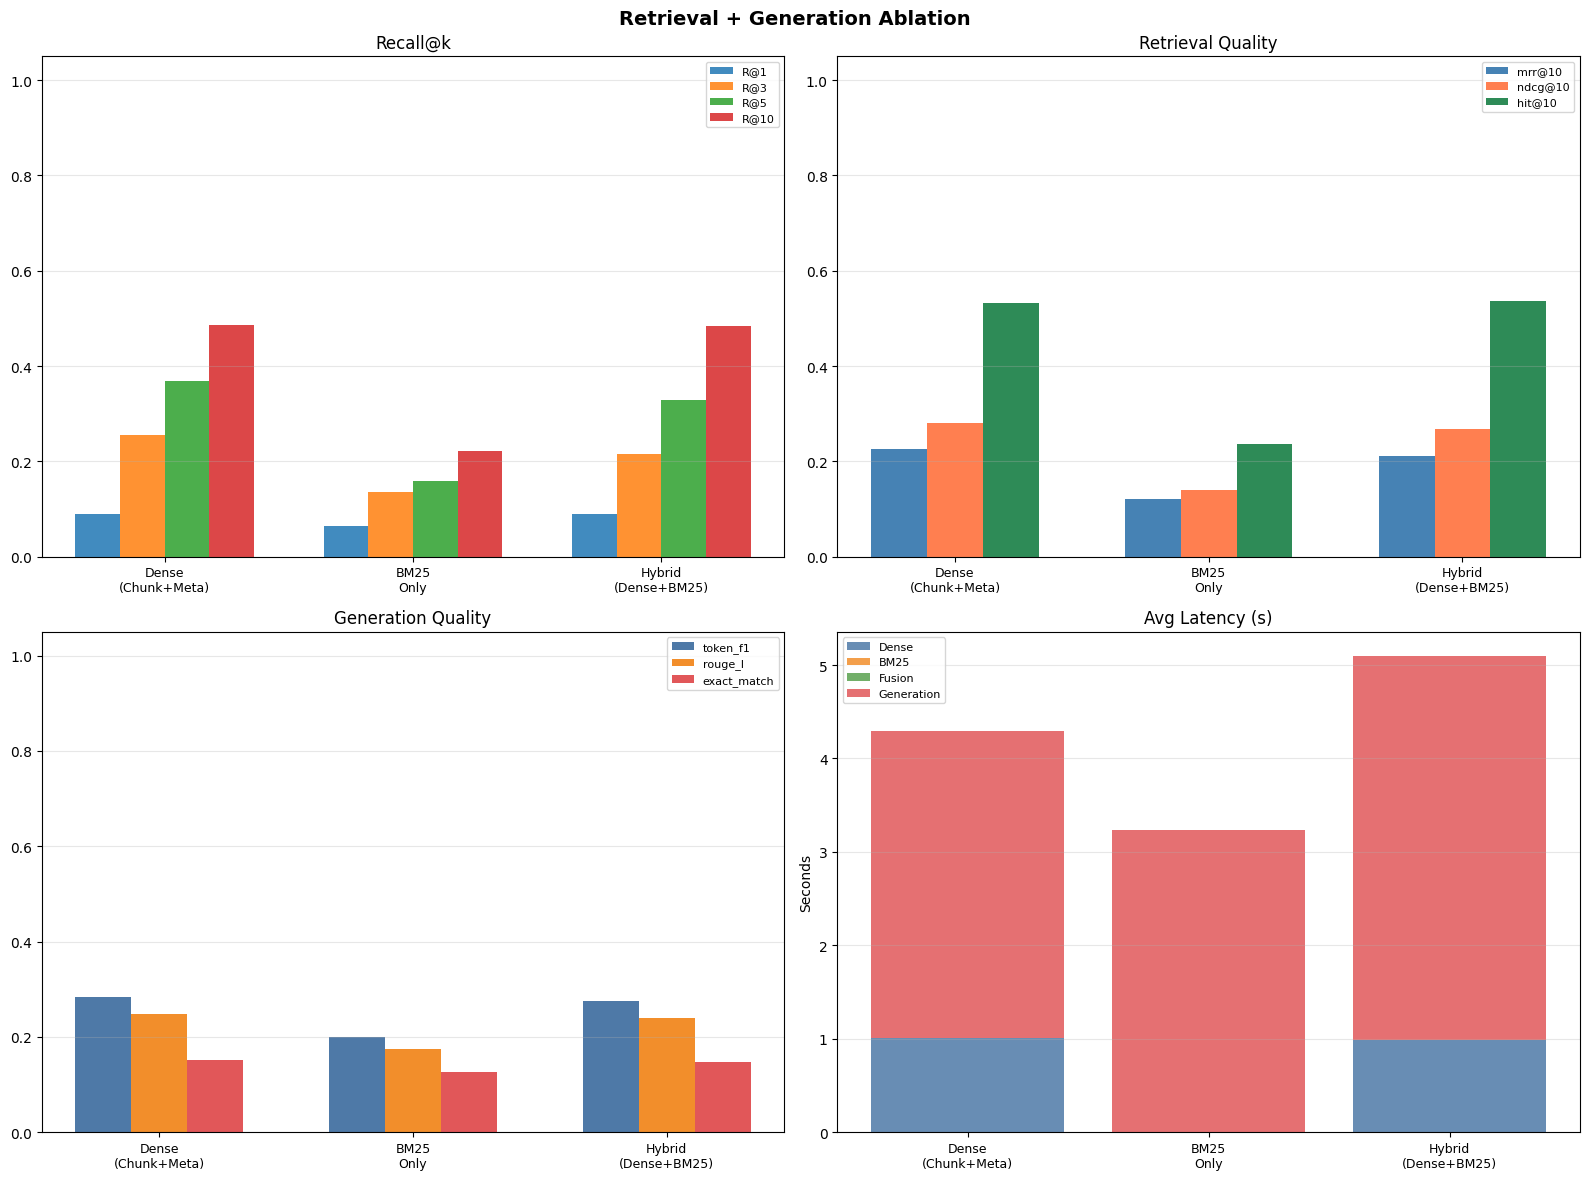

Saved /kaggle/working/evaluation_runs/ablation/charts.png


In [20]:
import matplotlib.pyplot as plt

cnames = list(all_results.keys())
short = ['Dense\n(Chunk+Meta)', 'BM25\nOnly', 'Hybrid\n(Dense+BM25)']
x = np.arange(len(cnames))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Retrieval + Generation Ablation', fontsize=14, fontweight='bold')

# Chart 1: Recall@k
ax = axes[0, 0]
w = 0.18
for i, k in enumerate(TOP_K_EVAL):
    v = [all_results[c][2]['overall'].get(f'recall@{k}',0) or 0 for c in cnames]
    ax.bar(x + i*w, v, w, label=f'R@{k}', alpha=0.85)
ax.set_xticks(x+w*1.5); ax.set_xticklabels(short, fontsize=9)
ax.set_title('Recall@k'); ax.legend(fontsize=8); ax.set_ylim(0,1.05); ax.grid(axis='y', alpha=0.3)

# Chart 2: MRR, nDCG, Hit@10
ax = axes[0, 1]
w = 0.22
for i, (m, clr) in enumerate([('mrr@10','steelblue'), ('ndcg@10','coral'), ('hit@10','seagreen')]):
    v = [all_results[c][2]['overall'].get(m,0) or 0 for c in cnames]
    ax.bar(x+(i-1)*w, v, w, label=m, color=clr)
ax.set_xticks(x); ax.set_xticklabels(short, fontsize=9)
ax.set_title('Retrieval Quality'); ax.legend(fontsize=8); ax.set_ylim(0,1.05); ax.grid(axis='y', alpha=0.3)

# Chart 3: Generation metrics
ax = axes[1, 0]
w = 0.22
for i, (m, clr) in enumerate([('token_f1','#4e79a7'), ('rouge_l','#f28e2b'), ('exact_match','#e15759')]):
    v = [all_results[c][2]['overall'].get(m,0) or 0 for c in cnames]
    ax.bar(x+(i-1)*w, v, w, label=m, color=clr)
ax.set_xticks(x); ax.set_xticklabels(short, fontsize=9)
ax.set_title('Generation Quality'); ax.legend(fontsize=8); ax.set_ylim(0,1.05); ax.grid(axis='y', alpha=0.3)

# Chart 4: Latency breakdown
ax = axes[1, 1]
stages = ['dense_latency_s','sparse_latency_s','fusion_latency_s','generation_latency_s']
slabels = ['Dense','BM25','Fusion','Generation']
scolors = ['#4e79a7','#f28e2b','#59a14f','#e15759']
bottom = np.zeros(len(cnames))
for st, lb, cl in zip(stages, slabels, scolors):
    vals = np.array([all_results[c][2]['latency']['avg'].get(st,0) for c in cnames])
    ax.bar(range(len(cnames)), vals, bottom=bottom, label=lb, color=cl, alpha=0.85)
    bottom += vals
ax.set_xticks(range(len(cnames))); ax.set_xticklabels(short, fontsize=9)
ax.set_title('Avg Latency (s)'); ax.legend(fontsize=8); ax.set_ylabel('Seconds'); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_BASE/'charts.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {OUTPUT_BASE}/charts.png')

## 13. Analysis

In [21]:
sd = all_results['Dense-ChunkMeta'][2]
sb = all_results['BM25-Only'][2]
sh = all_results['Retrieval-Hybrid-SparseDense'][2]

print('='*60)
print('NHẬN XÉT — Người 3 (Kiệt)')
print('='*60)

print('\n--- 1. RETRIEVAL: Dense vs BM25 ---')
for m in ['recall@5','recall@10','mrr@10','ndcg@10','hit@10']:
    d, b = sd['overall'].get(m,0) or 0, sb['overall'].get(m,0) or 0
    w = 'Dense' if d>b else 'BM25' if b>d else 'Tie'
    print(f'  {m:12s}: Dense={d:.4f}  BM25={b:.4f}  → {w}')

print('\n--- 2. RETRIEVAL: Hybrid vs Dense ---')
for m in ['recall@5','recall@10','mrr@10','ndcg@10']:
    d, h = sd['overall'].get(m,0) or 0, sh['overall'].get(m,0) or 0
    diff = h - d
    pct = (diff/d*100) if d else 0
    print(f'  {m:12s}: Dense={d:.4f}  Hybrid={h:.4f}  diff={diff:+.4f} ({pct:+.1f}%)')

print('\n--- 3. GENERATION: So sánh 3 configs ---')
for m in ['token_f1','rouge_l','exact_match']:
    d = sd['overall'].get(m) or 0
    b = sb['overall'].get(m) or 0
    h = sh['overall'].get(m) or 0
    best = 'Dense' if d>=b and d>=h else 'BM25' if b>=h else 'Hybrid'
    print(f'  {m:12s}: Dense={d:.4f}  BM25={b:.4f}  Hybrid={h:.4f}  → {best}')

print('\n--- 4. Best config? ---')
print(f'  {"Config":40s} {"R@10":>7s} {"MRR@10":>7s} {"F1":>7s} {"ROUGE":>7s} {"Lat":>7s}')
for c in all_results:
    s = all_results[c][2]
    r10 = s['overall'].get('recall@10',0) or 0
    mrr = s['overall'].get('mrr@10',0) or 0
    f1 = s['overall'].get('token_f1',0) or 0
    rl = s['overall'].get('rouge_l',0) or 0
    lat = s['latency']['avg'].get('total_latency_s',0)
    print(f'  {c:40s} {r10:>7.4f} {mrr:>7.4f} {f1:>7.4f} {rl:>7.4f} {lat:>6.2f}s')

print('\n' + '='*60)

NHẬN XÉT — Người 3 (Kiệt)

--- 1. RETRIEVAL: Dense vs BM25 ---
  recall@5    : Dense=0.3678  BM25=0.1585  → Dense
  recall@10   : Dense=0.4855  BM25=0.2225  → Dense
  mrr@10      : Dense=0.2267  BM25=0.1223  → Dense
  ndcg@10     : Dense=0.2813  BM25=0.1399  → Dense
  hit@10      : Dense=0.5325  BM25=0.2375  → Dense

--- 2. RETRIEVAL: Hybrid vs Dense ---
  recall@5    : Dense=0.3678  Hybrid=0.3291  diff=-0.0387 (-10.5%)
  recall@10   : Dense=0.4855  Hybrid=0.4842  diff=-0.0012 (-0.3%)
  mrr@10      : Dense=0.2267  Hybrid=0.2125  diff=-0.0142 (-6.3%)
  ndcg@10     : Dense=0.2813  Hybrid=0.2687  diff=-0.0126 (-4.5%)

--- 3. GENERATION: So sánh 3 configs ---
  token_f1    : Dense=0.2836  BM25=0.2006  Hybrid=0.2761  → Dense
  rouge_l     : Dense=0.2488  BM25=0.1747  Hybrid=0.2397  → Dense
  exact_match : Dense=0.1525  BM25=0.1275  Hybrid=0.1475  → Dense

--- 4. Best config? ---
  Config                                      R@10  MRR@10      F1   ROUGE     Lat
  Dense-ChunkMeta             

In [22]:
# Sample predictions
print('=== SAMPLE PREDICTIONS (first 3 answerable) ===')
for cn, (cases,_,_) in all_results.items():
    print(f'\n--- {cn} ---')
    shown = 0
    for c in cases:
        if c.get('is_unanswerable') or c.get('error'): continue
        print(f'  Q: {c["question"][:100]}...')
        print(f'  Ref: {c["reference_answer"][:150]}...')
        print(f'  Pred: {c["predicted_answer"][:150]}...')
        print(f'  EM={c.get("exact_match","?"):.1f} F1={c.get("token_f1","?"):.3f} ROUGE={c.get("rouge_l","?"):.3f} Citations={c.get("citation_count",0)}')
        print()
        shown += 1
        if shown >= 3: break

=== SAMPLE PREDICTIONS (first 3 answerable) ===

--- Dense-ChunkMeta ---
  Q: Nếu công ty tôi muốn xác minh lại quy định về chế độ tiền lương đối với cán bộ, công chức, viên chức...
  Ref: Nghị định số 204/2004/NĐ-CP ngày 14 tháng 12 năm 2004....
  Pred: Bạn nên dựa vào Thông tư 32/2015/TT-BTC để xác minh quy định về chế độ tiền lương đối với cán bộ, công chức, viên chức và lực lượng vũ trang mà cơ qua...
  EM=0.0 F1=0.036 ROUGE=0.036 Citations=1

  Q: Trong trường hợp tôi muốn biết thẩm quyền tuyển dụng công chức tại tỉnh Cà Mau hiện nay được thực hi...
  Ref: Thẩm quyền tuyển dụng công chức được thực hiện theo Quyết định số 038/2025/QĐ-UBND. Các văn bản cũ như Quyết định 48/2021/QĐ-UBND và các quy định liên...
  Pred: Thẩm quyền tuyển dụng công chức tại tỉnh Cà Mau hiện nay được thực hiện theo Quyết định 038/2025/QĐ-UBND. Những quy định cũ trước đây vẫn còn giá trị,...
  EM=0.0 F1=0.427 ROUGE=0.369 Citations=3

  Q: Doanh nghiệp của tôi trước đây có làm việc theo Quyết định 48/2021/Q

In [23]:
# Save combined summary
combined = {
    'owner': 'Người 3 (Kiệt)',
    'timestamp': datetime.now(timezone.utc).isoformat(),
    'description': 'Dense(chunk+meta), BM25, Hybrid + Generation (gpt-4o-mini)',
    'settings': {
        'embedding_model': EMBEDDING_MODEL, 'generator_model': LLM_MODEL,
        'top_k': TOP_K, 'top_n': TOP_N, 'eval_count': len(eval_qa),
    },
    'configs': {cn: {'overall': s['overall'], 'latency': s['latency'],
                     'by_category': s['by_category'], 'by_answer_type': s['by_answer_type']}
               for cn, (_,_,s) in all_results.items()},
}
with (OUTPUT_BASE/'summary.json').open('w', encoding='utf-8') as f:
    json.dump(combined, f, ensure_ascii=False, indent=2)

# Save comparison CSV
comp_rows = []
for cn, (_,_,s) in all_results.items():
    row = {'Config': cn}
    for k in ALL_METRIC_KEYS:
        v = s['overall'].get(k)
        row[k] = round(v, 4) if v is not None else None
    row['avg_gen_latency'] = round(s['latency']['avg'].get('generation_latency_s',0), 4)
    row['avg_total_latency'] = round(s['latency']['avg'].get('total_latency_s',0), 4)
    comp_rows.append(row)
pd.DataFrame(comp_rows).to_csv(OUTPUT_BASE/'comparison.csv', index=False)

print(f'Summary: {OUTPUT_BASE}/summary.json')
print(f'CSV: {OUTPUT_BASE}/comparison.csv')
print('✅ Done!')

Summary: /kaggle/working/evaluation_runs/ablation/summary.json
CSV: /kaggle/working/evaluation_runs/ablation/comparison.csv
✅ Done!


## 14. Download (Kaggle)

In [24]:
import shutil
if IS_KAGGLE:
    shutil.make_archive('/kaggle/working/ablation_results', 'zip', str(OUTPUT_BASE))
    print('✅ /kaggle/working/ablation_results.zip')

for p in sorted(OUTPUT_BASE.rglob('*')):
    if p.is_file(): print(f'  {p.relative_to(OUTPUT_BASE)} ({p.stat().st_size/1024:.0f}KB)')

✅ /kaggle/working/ablation_results.zip
  BM25-Only/latency.json (0KB)
  BM25-Only/manifest.json (1KB)
  BM25-Only/retrieval_cases.jsonl (751KB)
  BM25-Only/retrieval_metrics.json (12KB)
  Dense-ChunkMeta/latency.json (0KB)
  Dense-ChunkMeta/manifest.json (1KB)
  Dense-ChunkMeta/retrieval_cases.jsonl (759KB)
  Dense-ChunkMeta/retrieval_metrics.json (12KB)
  Retrieval-Hybrid-SparseDense/latency.json (0KB)
  Retrieval-Hybrid-SparseDense/manifest.json (1KB)
  Retrieval-Hybrid-SparseDense/retrieval_cases.jsonl (764KB)
  Retrieval-Hybrid-SparseDense/retrieval_metrics.json (12KB)
  charts.png (104KB)
  comparison.csv (1KB)
  summary.json (31KB)
